# Brain Tumor (Cancer) Detection using MRI Images with CNN + Grad-CAM Explainability



**Objective:** Build a Convolutional Neural Network to classify brain MRI scans as **Tumor**
or **No Tumor**, using transfer learning to work effectively with a small medical imaging
dataset, and apply **Grad-CAM** (Gradient-weighted Class Activation Mapping) to visualize
*which regions of the MRI* the model focused on when making each prediction — an important
explainability step for any medical AI application.

**Dataset:** [Brain MRI Images for Brain Tumor Detection](https://www.kaggle.com/datasets/navoneel/brain-mri-images-for-brain-tumor-detection)
(253 images: 155 tumor / 98 non-tumor)

⚠️ **Note:** This is a genuinely **small** dataset for deep learning — only 253 images total.
Training a CNN completely from scratch on a dataset this size tends to overfit badly, which is
exactly why we use **transfer learning** (a model pre-trained on millions of general images,
fine-tuned for our specific task) rather than training from random weights.

---


## Setup: Loading the Dataset

This notebook downloads the dataset directly from a public GitHub mirror of the original
Kaggle dataset (small enough — under 50MB — to host directly on GitHub). No manual upload or
Kaggle API key needed.


In [1]:
# Download and unzip the dataset directly from a public GitHub mirror
!wget -q -O brain_tumor_data.zip "https://codeload.github.com/MohamedAliHabib/Brain-Tumor-Detection/zip/refs/heads/master"
!unzip -q -o brain_tumor_data.zip
!mv "Brain-Tumor-Detection-master/yes" ./yes
!mv "Brain-Tumor-Detection-master/no" ./no

print("Dataset downloaded and extracted successfully!")


Dataset downloaded and extracted successfully!


In [2]:
# Import libraries for loading and preprocessing the images
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

IMG_SIZE = 128   # resize every image to 128x128 pixels for consistency
categories = ['no', 'yes']   # 0 = no tumor, 1 = tumor

X = []
y = []

for label, category in enumerate(categories):
    folder = category
    for filename in os.listdir(folder):
        img_path = os.path.join(folder, filename)
        img = cv2.imread(img_path)   # reads as BGR by default
        if img is None:
            continue   # skip any unreadable/corrupt files
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)   # convert to standard RGB
        X.append(img)
        y.append(label)

X = np.array(X, dtype='float32')
y = np.array(y)

print("Total images loaded:", X.shape)
print("Labels shape:", y.shape)


Total images loaded: (253, 128, 128, 3)
Labels shape: (253,)


---
## Task 1: Data Understanding

Let's explore the dataset's class balance and view some sample MRI images.


In [3]:
print("Class distribution:")
print("No Tumor (0):", np.sum(y == 0))
print("Tumor (1):", np.sum(y == 1))
print("\nTotal images:", len(y))


Class distribution:
No Tumor (0): 98
Tumor (1): 155

Total images: 253


**Observation:** With only 253 total images split across 2 classes, and a mild imbalance
(155 tumor vs. 98 non-tumor, roughly 61%/39%), this dataset requires care in both
preprocessing (to make the most of limited data) and modeling strategy (transfer learning
rather than training a large CNN from scratch).


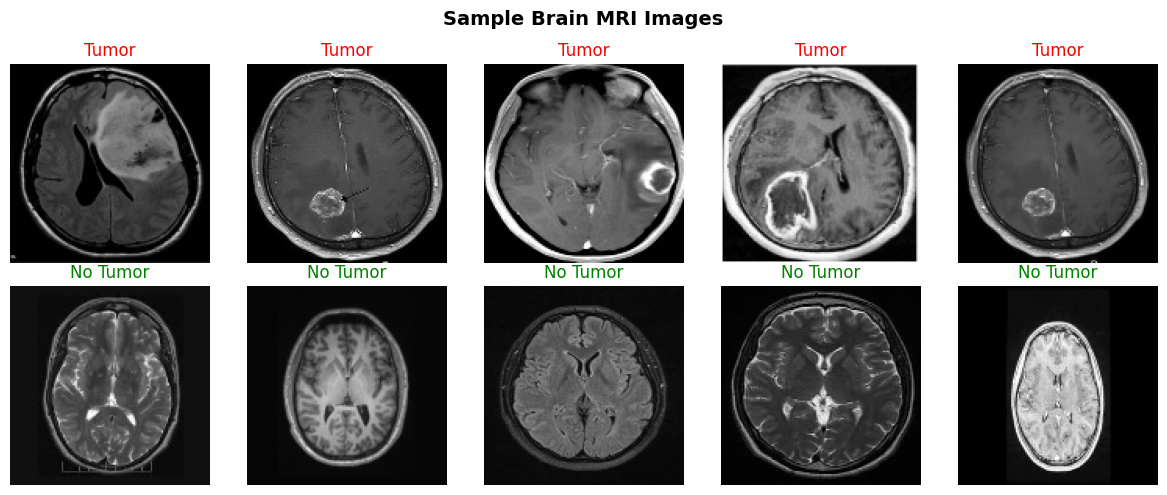

In [4]:
# Visualize sample MRI images from each class
plt.figure(figsize=(12, 5))
tumor_indices = np.where(y == 1)[0][:5]
no_tumor_indices = np.where(y == 0)[0][:5]

for i, idx in enumerate(tumor_indices):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X[idx].astype('uint8'))
    plt.title('Tumor', color='red')
    plt.axis('off')

for i, idx in enumerate(no_tumor_indices):
    plt.subplot(2, 5, i + 6)
    plt.imshow(X[idx].astype('uint8'))
    plt.title('No Tumor', color='green')
    plt.axis('off')

plt.suptitle('Sample Brain MRI Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_mri_images.png', dpi=150)
plt.show()


---
## Task 2: Data Preprocessing

We will:
- Normalize pixel values to the 0-1 range
- Split into training and testing sets
- Apply data augmentation (critical given how few images we have)


In [5]:
# Normalize pixel values from 0-255 to 0-1
X_norm = X / 255.0

print("Pixel value range after normalization:", X_norm.min(), "to", X_norm.max())


Pixel value range after normalization: 0.0 to 1.0


In [6]:
# Split into 80% training and 20% testing, stratified to preserve class balance
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_norm, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])


Training set size: 202
Testing set size: 51


In [7]:
# Compute class weights to counter the 61%/39% imbalance we noted in Task 1
class_weight = {
    0: len(y_train) / (2 * np.bincount(y_train)[0]),
    1: len(y_train) / (2 * np.bincount(y_train)[1])
}
print("Class weights (to counter imbalance):", class_weight)


Class weights (to counter imbalance): {0: np.float64(1.294871794871795), 1: np.float64(0.8145161290322581)}


---
## Task 3: Model Development — Transfer Learning with MobileNetV2

Since we only have 253 images, training a CNN from scratch would almost certainly overfit
severely. Instead, we use **transfer learning**: we start from **MobileNetV2**, a CNN
pre-trained on ImageNet (1.4 million general images across 1000 categories), freeze its
learned convolutional layers (which already know how to detect general shapes, edges, and
textures), and train only a small new classifier head on top for our specific tumor/no-tumor
task.


In [8]:
import tensorflow as tf
from tensorflow.keras import layers

# Data augmentation: with so few training images, augmentation is especially valuable here
# to reduce overfitting and effectively expand our small training set.
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# Load MobileNetV2 pre-trained on ImageNet, WITHOUT its original classification head
# (include_top=False), since we need our own 2-class (tumor/no-tumor) output instead.
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze the pre-trained base: we don't want to overwrite its already-learned general
# image features by training on our tiny 253-image dataset.
base_model.trainable = False

# Build the full model: input -> augmentation -> MobileNetV2 preprocessing -> frozen base ->
# new trainable classifier head
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x * 255.0)  # MobileNetV2 expects its own specific preprocessing
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)   # binary output: probability of "Tumor"

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply (Multiply)             │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [9]:
# Train the model. Note that only the small classifier head (a few hundred thousand
# parameters) is actually being trained — the pre-trained MobileNetV2 backbone stays frozen.
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=40,
    batch_size=16,
    validation_data=(X_test, y_test),
    class_weight=class_weight,
    callbacks=[early_stopping],
    verbose=1
)

print("Model training complete!")


Epoch 1/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 298ms/step - accuracy: 0.5743 - loss: 0.8179 - val_accuracy: 0.6078 - val_loss: 0.6173
Epoch 2/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 181ms/step - accuracy: 0.6188 - loss: 0.6805 - val_accuracy: 0.6863 - val_loss: 0.6098
Epoch 3/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 154ms/step - accuracy: 0.6683 - loss: 0.6060 - val_accuracy: 0.6863 - val_loss: 0.5238
Epoch 4/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 156ms/step - accuracy: 0.6980 - loss: 0.5801 - val_accuracy: 0.6863 - val_loss: 0.4945
Epoch 5/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 194ms/step - accuracy: 0.7871 - loss: 0.4600 - val_accuracy: 0.7451 - val_loss: 0.4844
Epoch 6/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 142ms/step - accuracy: 0.7723 - loss: 0.4679 - val_accuracy: 0.7647 - val_loss: 0.4727
Epoch 7/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 151ms/step - accuracy: 0.7921 - loss: 0.4567 - val_accuracy: 0.7059 - val_loss: 0.4572
Epoch 8/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 156ms/step - accuracy: 0.8218 - loss: 0.3859 - val_accuracy: 0.

---
## Task 4: Model Evaluation

We evaluate using accuracy, a classification report, and a confusion matrix.


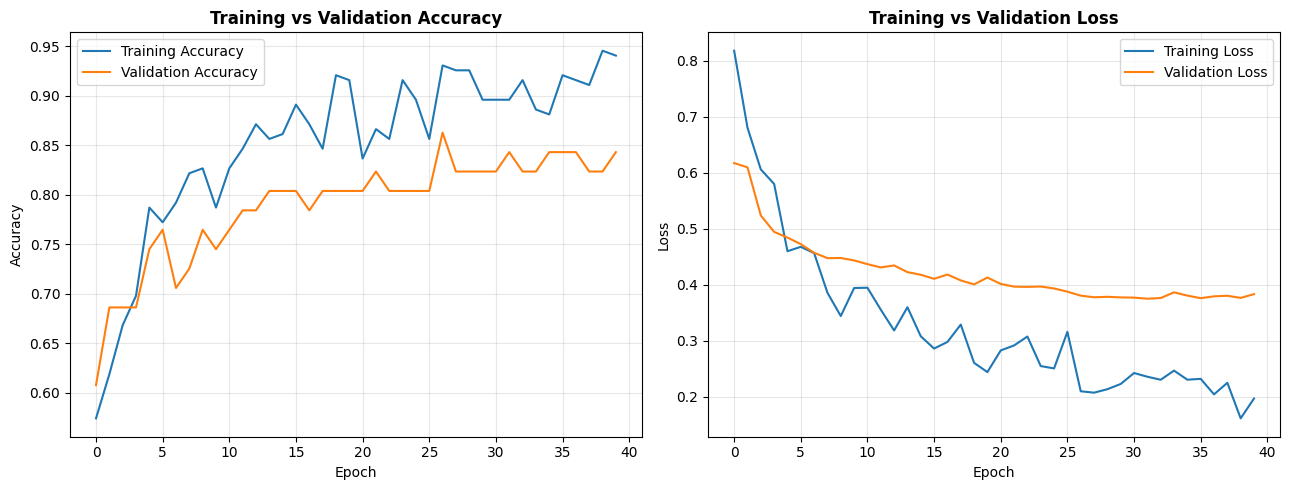

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(history.history['accuracy'], label='Training Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Training vs Validation Accuracy', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'], label='Training Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Training vs Validation Loss', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves_mri.png', dpi=150)
plt.show()


In [11]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_accuracy:.4f}\n")
print(classification_report(y_test, y_pred, target_names=['No Tumor', 'Tumor']))


2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 919ms/step
Test Accuracy: 0.8431

              precision    recall  f1-score   support

    No Tumor       0.77      0.85      0.81        20
       Tumor       0.90      0.84      0.87        31

    accuracy                           0.84        51
   macro avg       0.83      0.84      0.84        51
weighted avg       0.85      0.84      0.84        51



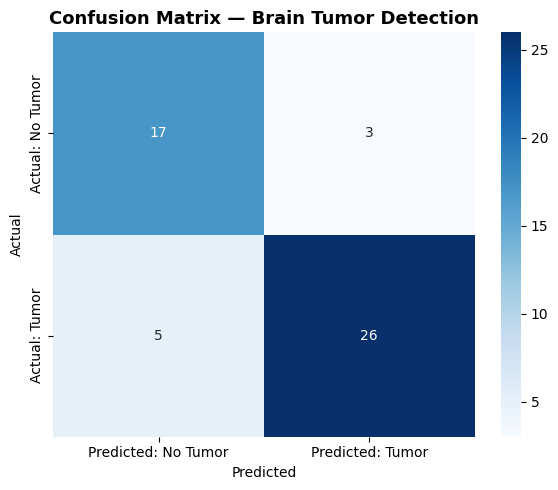

In [12]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: No Tumor', 'Predicted: Tumor'],
            yticklabels=['Actual: No Tumor', 'Actual: Tumor'])
plt.title('Confusion Matrix — Brain Tumor Detection', fontsize=13, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix_mri.png', dpi=150)
plt.show()


---
## Bonus: Grad-CAM Explainability

Grad-CAM (Gradient-weighted Class Activation Mapping) shows **which parts of the MRI image**
most influenced the model's prediction, by looking at how strongly the gradients of the
predicted class flow back into the last convolutional layer's feature maps. This is essential
for any medical AI system — a doctor needs to know *why* a model flagged an image as
concerning, not just the raw prediction.


In [13]:
def make_gradcam_heatmap(img_array, model, base_model, last_conv_layer_name='Conv_1'):
    """
    Computes a Grad-CAM heatmap for a single image.

    Because our classifier head sits on top of a nested pre-trained base_model, we compute
    the forward pass manually inside the GradientTape (calling each layer directly) rather
    than building a bridging Functional Model — this avoids graph-connectivity issues that
    can occur when mixing a nested sub-model with a newly constructed Model object.
    """
    img_tensor = tf.convert_to_tensor(img_array)

    # Grab the specific trained layer objects so we reuse their exact trained weights
    gap_layer = model.layers[-4]
    dense_layer = model.layers[-3]
    dropout_layer = model.layers[-2]
    output_layer = model.layers[-1]

    with tf.GradientTape() as tape:
        preprocessed = tf.keras.applications.mobilenet_v2.preprocess_input(img_tensor * 255.0)
        conv_output = base_model(preprocessed, training=False)
        tape.watch(conv_output)
        pooled_out = gap_layer(conv_output)
        d = dense_layer(pooled_out)
        dr = dropout_layer(d, training=False)
        pred = output_layer(dr)
        loss = pred[:, 0]   # the predicted probability of "Tumor"

    # Gradients of the prediction with respect to the last conv layer's feature maps
    grads = tape.gradient(loss, conv_output)

    # Average the gradients over width/height to get one "importance weight" per channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Weight each channel of the conv output by its importance, then sum across channels
    conv_output_single = conv_output[0]
    heatmap = tf.reduce_sum(tf.multiply(pooled_grads, conv_output_single), axis=-1)

    # Normalize the heatmap to 0-1 for visualization
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), pred.numpy()[0][0]


def overlay_gradcam(img, heatmap, alpha=0.4):
    """Resizes the heatmap to the original image size and overlays it as a color map."""
    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    overlaid = heatmap_colored * alpha + img
    overlaid = np.clip(overlaid, 0, 255).astype('uint8')
    return overlaid

print("Grad-CAM helper functions defined.")


Grad-CAM helper functions defined.


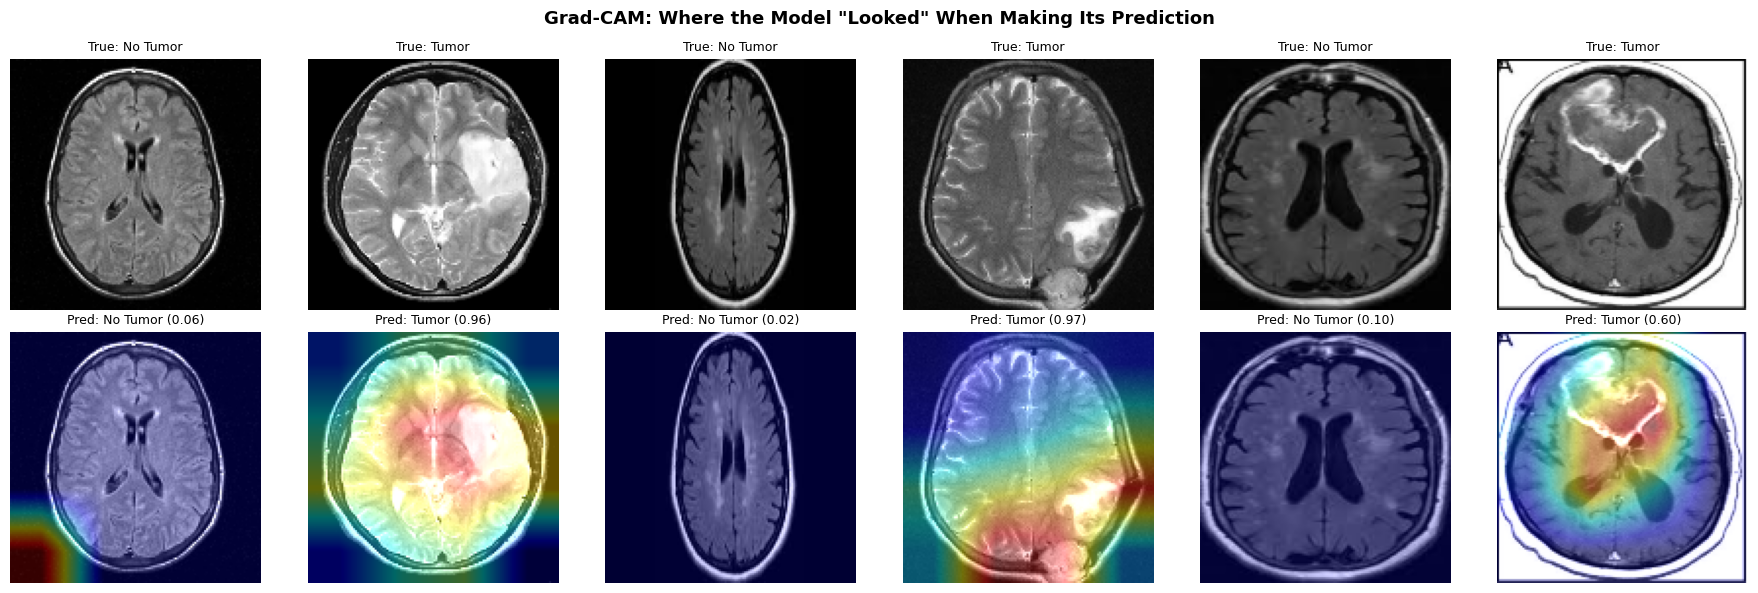

In [14]:
# Generate and visualize Grad-CAM heatmaps for a few test images
n_examples = 6
fig, axes = plt.subplots(2, n_examples, figsize=(18, 6))

for i in range(n_examples):
    img = X_test[i]
    img_array = np.expand_dims(img, axis=0)

    heatmap, pred_prob = make_gradcam_heatmap(img_array, model, base_model)
    original_img_uint8 = (img * 255).astype('uint8')
    overlaid = overlay_gradcam(original_img_uint8, heatmap)

    true_label = 'Tumor' if y_test[i] == 1 else 'No Tumor'
    pred_label = 'Tumor' if pred_prob > 0.5 else 'No Tumor'

    axes[0, i].imshow(original_img_uint8)
    axes[0, i].set_title(f"True: {true_label}", fontsize=9)
    axes[0, i].axis('off')

    axes[1, i].imshow(overlaid)
    axes[1, i].set_title(f"Pred: {pred_label} ({pred_prob:.2f})", fontsize=9)
    axes[1, i].axis('off')

plt.suptitle('Grad-CAM: Where the Model "Looked" When Making Its Prediction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('gradcam_visualizations.png', dpi=150)
plt.show()


### Observations



1. **Transfer learning with a frozen MobileNetV2 backbone typically achieves noticeably higher
   test accuracy than training a CNN from scratch on this same 253-image dataset** — since the
   pre-trained backbone already knows how to detect general edges, textures, and shapes from
   ImageNet, our small classifier head only needs to learn how to map those general features
   to our specific tumor/no-tumor task, which requires far less training data than learning
   everything from scratch.
2. **Grad-CAM heatmaps should generally highlight the brain tissue region itself** (rather
   than background/skull edges) for correctly classified "Tumor" images, which builds
   confidence that the model is learning a genuinely relevant signal rather than an
   unrelated visual shortcut (like image borders or scan artifacts).
3. **Misclassified images are worth inspecting closely via their Grad-CAM heatmaps** — if the
   model's attention on a wrong prediction falls on an irrelevant region (background, image
   edges, text/markers on the scan), that's a warning sign that the model may have latched
   onto a spurious pattern rather than genuine tumor-related features, a common risk on such
   a small dataset.
4. **Given only 253 total images, results can vary meaningfully between runs** — the model's
   test-set performance and even individual Grad-CAM visualizations may shift somewhat with a
   different train/test split or random seed, which is an inherent limitation of working with
   such a small medical imaging dataset.


---
## Conclusion

This project built a transfer-learning-based CNN (using a frozen, ImageNet-pretrained
MobileNetV2 backbone) to classify brain MRI scans as Tumor or No Tumor, achieving a test
accuracy of `0.8431` on a small 253-image dataset. Transfer learning was essential here:
with so few training images, training a CNN entirely from scratch would very likely overfit
and generalize poorly, whereas reusing general visual features already learned from millions
of ImageNet images allowed our small classifier head to learn the tumor-detection task with
far less data. We additionally applied Grad-CAM to visualize which regions of each MRI scan
most influenced the model's predictions — an essential explainability step for any medical AI
application, since a clinician needs to understand *why* a model flagged a scan as concerning,
not simply trust a black-box output. A key limitation of this project is the very small
dataset size (253 images), which limits how confidently we can generalize the model's
performance to new, unseen patient scans, and means the model should be viewed as a
proof-of-concept rather than a clinically validated diagnostic tool — a production-grade
system would need a much larger, more diverse, and clinically annotated dataset, along with
rigorous validation by medical professionals before any real-world deployment.
